In [60]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve
from numpy.polynomial.legendre import leggauss
import torch
from scipy.linalg import eigh
from scipy.linalg import solve

!git clone https://github.com/Philipp3011/Parareal-OCP-Convergence-tests-bachelor-thesis.git
%cd Parareal-OCP-Convergence-tests-bachelor-thesis

from parareal_grundfunktionen import *
from propagators import FP, BE, SDIRK22


%cd /content

fatal: destination path 'Parareal-OCP-Convergence-tests-bachelor-thesis' already exists and is not an empty directory.
/content/Parareal-OCP-Convergence-tests-bachelor-thesis
/content


In [61]:
def parareal_error_for_plot(CP_method, FP_method, J, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine=None, K=25):

    delta_T = (t_end - t_0) / int(N / J)

    U_fine = U_fine_full[::J]

    P_i_sum_CP, R_T_A_h_CP = prepare_CP(delta_T, A_h, CP_method["P"], CP_method["R"])

    if RHS_values_fine is None:
        RHS_values_CP = None
    else:
        RHS_values_CP = prepare_rhs(CP_method["C"], f, mass, delta_T, T_intervall, M, OMEGA)

    _, error = parareal_fehlervergleich(RHS_values_CP, RHS_values_fine, R_T_A_h_CP, R_T_A_h_fine,
                                        P_i_sum_CP, P_i_sum_fine, CP, T_intervall, U_fine, M, N, J, u_0, f,
                                        CP_method["R"], FP_method["R"], CP_method["P"], FP_method["P"],
                                        CP_method["C"], FP_method["C"], K, A_h, stiff, mass, v_h)
    return error


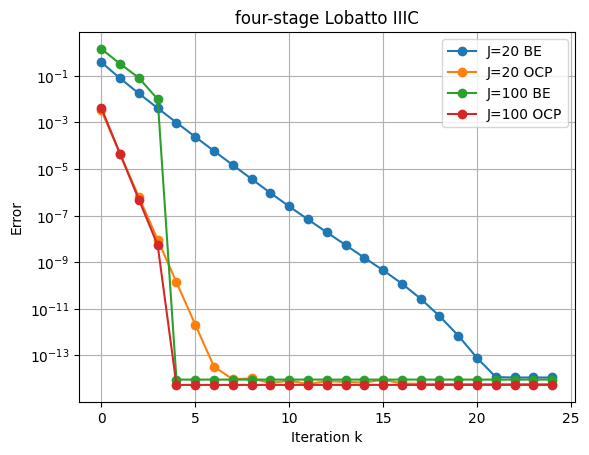

In [62]:
# Example Section 3.4 "first numerical illustration"

def u0_a(x):
    return (x**10) * ((x-np.pi)**10) * ((np.pi/2)**(-10))

def f_a(x, t):
    return 0

M = 100
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_a
f = f_a

t_0, t_end = T_intervall

# Spatial discretization
tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

stiff, mass = matrix(M, OMEGA, inner_tri)
A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

#fine propagator and precalculated values
fp = FP["LobattoIIIC4"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_CP(delta_t, A_h, fp["P"], fp["R"])

# f = 0, therefore RHS_values = None
RHS_values_fine = prepare_rhs(fp["C"], f, mass, delta_t, T_intervall, M, OMEGA)
U_fine_full = calculate_U(RHS_values_fine, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA, mesh, u_0, T_intervall, fp["R"], fp["P"], fp["C"], A_h, mass, v_h)

OCP_J20 = load_OCP("models/n1m2_001_100_LOBATTOIIIC4_J20.pt")
OCP_J100 = load_OCP("models/n1m2_001_100_LOBATTOIIIC4_J100.pt")


J = 20
K = int(N /J)
delta_T = (t_end - t_0) / int(N /J)

error_BE_J20 = parareal_error_for_plot(BE, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J20 = parareal_error_for_plot(OCP, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_BE_J100 = parareal_error_for_plot(BE, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J100 = parareal_error_for_plot(OCP, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

#creating the plot
plt.plot(error_BE_J20, marker="o", label="J=20 BE")
plt.plot(error_OCP_J20, marker="o", label="J=20 OCP")
plt.plot(error_BE_J100, marker="o", label="J=100 BE")
plt.plot(error_OCP_J100, marker="o", label="J=100 OCP")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("four-stage Lobatto IIIC")
plt.grid(True)
plt.legend()
plt.show()



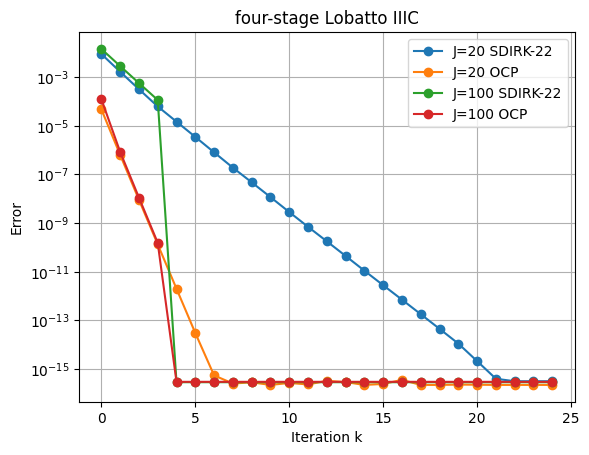

In [63]:
# Example 5.1 (b)

def u0_b(x):
    return np.where(
        (x > 0) & (x < np.pi/2),
        1.0,
        0.0
    )

def f_b(x, t):
    return np.cos(t) * np.sin(x)

M = 100
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_b
f = f_b

t_0, t_end = T_intervall

# Spatial discretization
tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

stiff, mass = matrix(M, OMEGA, inner_tri)
A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

# Fine propagator and precalculated values
fp = FP["LobattoIIIC4"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_CP(delta_t, A_h, fp["P"], fp["R"])
RHS_values_fine = prepare_rhs(fp["C"], f, mass, delta_t, T_intervall, M, OMEGA)

U_fine_full = calculate_U(RHS_values_fine, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA, mesh, u_0,
                          T_intervall, fp["R"], fp["P"], fp["C"], A_h, mass, v_h)


OCP_J20 = load_OCP("models/n1m2_001_100_LOBATTOIIIC4_J20.pt")
OCP_J100 = load_OCP("models/n1m2_001_100_LOBATTOIIIC4_J100.pt")

J = 20
K = int(N/J)
delta_T = (t_end - t_0) / int(N/J)

error_SDIRK_J20 = parareal_error_for_plot(SDIRK22, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine)

error_OCP_J20 = parareal_error_for_plot(OCP_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine)

error_SDIRK_J100 = parareal_error_for_plot(SDIRK22, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine)

error_OCP_J100 = parareal_error_for_plot(OCP_J100, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine)


# Creating the plot
plt.plot(error_SDIRK_J20, marker="o", label="J=20 SDIRK-22")
plt.plot(error_OCP_J20, marker="o", label="J=20 OCP")
plt.plot(error_SDIRK_J100, marker="o", label="J=100 SDIRK-22")
plt.plot(error_OCP_J100, marker="o", label="J=100 OCP")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("four-stage Lobatto IIIC")
plt.grid(True)
plt.legend()
plt.show()

In [64]:

# This function only works for homogeneous euations, however the previous function, which used
# prepare_CP does not work for this example nad the n2m4 OCP, because of an error regarding
# machine precision. This function prepare_R_spectral was used to generate the last two
# plots in the bachelor thesis, where this example was used.

def parareal_error_scalar_for_plot(CP_method, FP_method, J, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25):

    delta_T = J * ((t_end - t_0) / N)

    U_fine = U_fine_full[::J]

    if "R_scalar" in CP_method:
        P_i_sum_CP, R_T_A_h_CP = prepare_R_spectral(delta_T, CP_method["R_scalar"], eigenvalues, eigenvectors, eigenvectors_inverse)

    else:
        P_i_sum_CP, R_T_A_h_CP = prepare_CP(delta_T, A_h, CP_method["P"], CP_method["R"])


    _, error = parareal_fehlervergleich(None, None, R_T_A_h_CP, R_T_A_h_fine,
                                        P_i_sum_CP, P_i_sum_fine, CP, T_intervall, U_fine, M, N, J, u_0, f,
                                        CP_method["R"], FP_method["R"], CP_method["P"], FP_method["P"],
                                        CP_method["C"], FP_method["C"], K, A_h, stiff, mass, v_h)

    return error

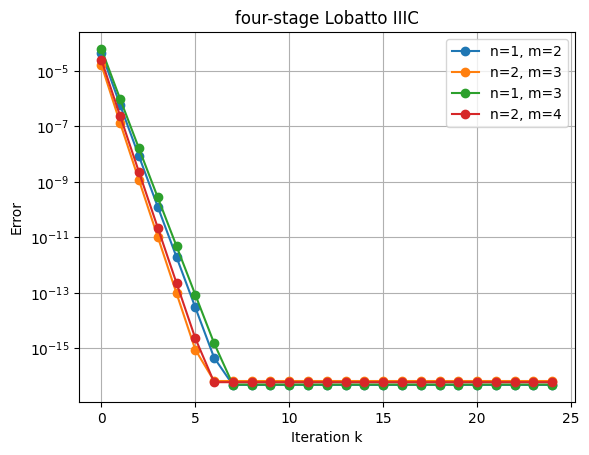

In [79]:
from os import fpathconf
#Example 5.3

def a(x):
    if x < np.pi/2:
        return 1.0
    else:
        return 10000.0

def u0_2(x):
    return np.where((x > np.pi/4) & (x < 3*np.pi/4), 1.0, 0.0)


def f_2(x, t):
    return 0.0

M= 100
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_2
f = f_2

t_0, t_end = T_intervall

# Spatial discretization

tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

_, mass = matrix(M, OMEGA, inner_tri)
stiff = dsicrete_operator_div_a_grad_u(
    M, OMEGA, inner_tri, a, quad_order=3
)

A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

# Eigenvalue decomposition used for the spectral evaluation
eigenvalues, eigenvectors = eigh(stiff, mass)
eigenvectors_inverse = eigenvectors.T @ mass


# Fine propagator and precalculated values
fp = FP["LobattoIIIC4"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_R_spectral(delta_t, fp["R_scalar"], eigenvalues, eigenvectors, eigenvectors_inverse)


U_fine_full = calculate_U(None, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA,
                          mesh, u_0, T_intervall, fp["R"], fp["P"], fp["C"],
                          A_h, mass, v_h)


OCP_J20_n1m2 = load_OCP("models/n1m2_001_100_LOBATTOIIIC4_J20.pt")
OCP_J20_n2m3 = load_OCP("models/n2m3_001_100_LOBATTOIIIC4_J20.pt")
OCP_J20_n1m3 = load_OCP("models/n1m3_001_100_LOBATTOIIIC4_J20.pt")
OCP_J20_n2m4 = load_OCP("models/n2m4_001_100_LOBATTOIIIC4_J20.pt")

error_OCP_n1m2 = parareal_error_scalar_for_plot(OCP_J20_n1m2, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25)

error_OCP_n2m3 = parareal_error_scalar_for_plot(OCP_J20_n2m3, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25)

error_OCP_n1m3 = parareal_error_scalar_for_plot(OCP_J20_n1m3, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25)

error_OCP_n2m4 = parareal_error_scalar_for_plot(OCP_J20_n2m4, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25)


plt.plot(error_OCP_n1m2, marker="o", label="n=1, m=2")
plt.plot(error_OCP_n2m3, marker="o", label="n=2, m=3")
plt.plot(error_OCP_n1m3, marker="o", label="n=1, m=3")
plt.plot(error_OCP_n2m4, marker="o", label="n=2, m=4")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("four-stage Lobatto IIIC")
plt.grid(True)
plt.legend()
plt.show()